libraries



In [2]:
# ── Standard Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# ── NLP ──
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# ── ML ──
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Deep Learning ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print("libraries import")
print(f"TensorFlow version: {tf.__version__}")


libraries import
TensorFlow version: 2.21.0


Dataload

In [3]:
# Fake.csv and True.csv dataset load  
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

# Label add 
fake_df['label'] = 'FAKE'
true_df['label'] = 'REAL'

# both join 
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(' Dataset Shape:', df.shape)
print('\n Columns:', df.columns.tolist())
print('\n  Label Distribution:')
print(df['label'].value_counts())




 Dataset Shape: (44898, 5)

 Columns: ['title', 'text', 'subject', 'date', 'label']

  Label Distribution:
label
FAKE    23481
REAL    21417
Name: count, dtype: int64


In [4]:
df.head(5)

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL


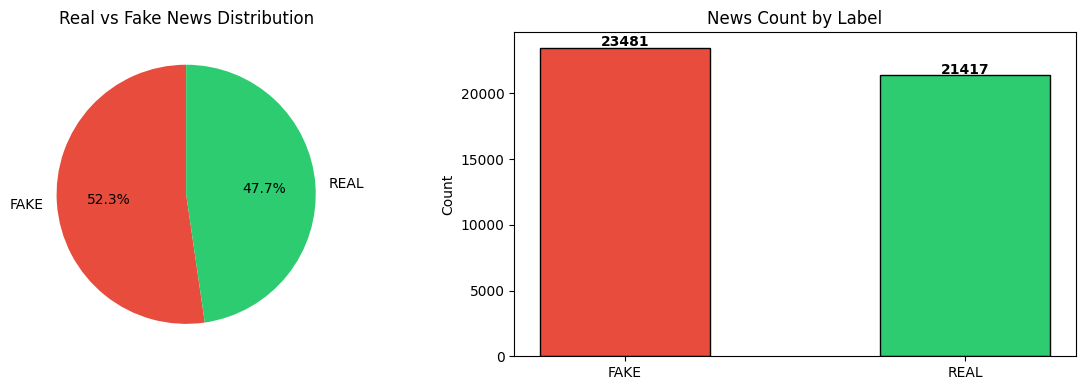

In [5]:
# Pie chart and Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
label_counts = df['label'].value_counts()
axes[0].pie(label_counts, labels=label_counts.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90)
axes[0].set_title('Real vs Fake News Distribution')

# Bar chart
axes[1].bar(label_counts.index, label_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[1].set_title('News Count by Label')
axes[1].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Text Preprocessing

In [6]:
# Text clean function
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Special characters remove 
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Stopwords remove 
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

# Title column drop 
df = df.drop(columns=['title', 'subject', 'date'])

# Null values drop 
df = df.dropna().reset_index(drop=True)

# Text clean 
print(' Text cleaning....')
df['clean_text'] = df['text'].apply(preprocess_text)

print(' Preprocessing complete!')
print('\nOriginal text:')
print(df['text'].iloc[0][:150])
print('\nClean text:')
print(df['clean_text'].iloc[0][:150])


 Text cleaning....
 Preprocessing complete!

Original text:
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as

Clean text:
st century wire says ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ferris bueller day made provocat


Data Split and TF-IDF


In [7]:
# X and y define 
X = df['clean_text']
y = df['label']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f' Training set:  {len(X_train)} samples')
print(f' Testing set:   {len(X_test)} samples')

# TF-IDF Vectorization
print('\n TF-IDF Vectorization...')
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(' Vectorization done!')


 Training set:  35918 samples
 Testing set:   8980 samples

 TF-IDF Vectorization...
 Vectorization done!


 ML Models Train 

In [8]:
# 5 ML Models define 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(),
    'Random Forest':       RandomForestClassifier(n_estimators=100),
    'Multinomial NB':      MultinomialNB(),
    'KNeighbors':          KNeighborsClassifier(n_neighbors=5),
}

ml_results = {}

print(f"{'Algorithm':<22} {'Train Acc':>11} {'Test Acc':>10}")
print('─' * 46)

for name, model in models.items():
    print(f' {name} training....')
    model.fit(X_train_vec, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train_vec))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_vec))
    
    ml_results[name] = {'model': model, 'train': train_acc, 'test': test_acc}
    print(f'{name:<22} {train_acc:>11.4f} {test_acc:>10.4f}')

print('\n All models are trained!')

Algorithm                Train Acc   Test Acc
──────────────────────────────────────────────
 Logistic Regression training....
Logistic Regression         0.9930     0.9870
 Decision Tree training....
Decision Tree               1.0000     0.9954
 Random Forest training....
Random Forest               1.0000     0.9977
 Multinomial NB training....
Multinomial NB              0.9411     0.9347
 KNeighbors training....
KNeighbors                  0.7381     0.6947

 All models are trained!


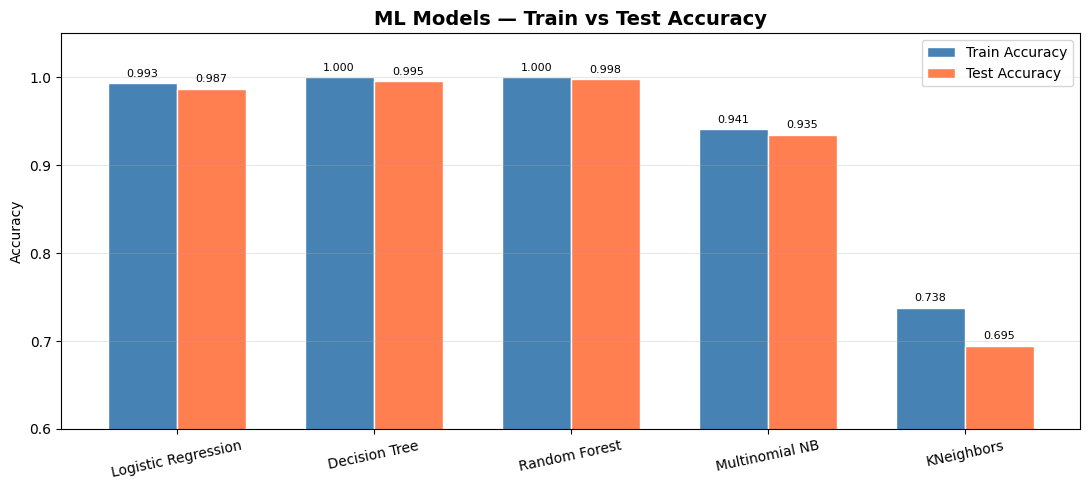

In [9]:
# Accuracy Comparison Chart
names      = list(ml_results.keys())
train_accs = [ml_results[n]['train'] for n in names]
test_accs  = [ml_results[n]['test']  for n in names]

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy',
            color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',
            color='coral', edgecolor='white')

ax.set_title('ML Models — Train vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=12)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

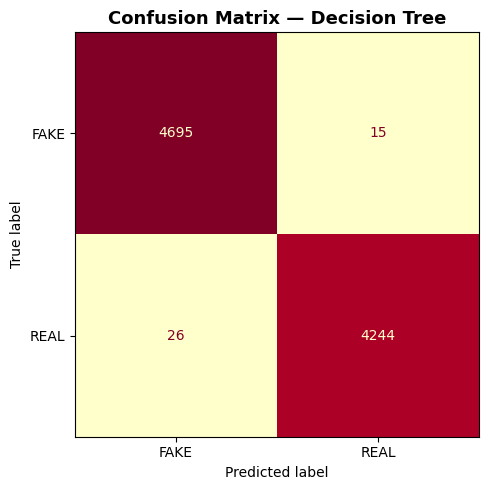


 Confusion Matrix Explanation:
 Correctly predicted FAKE:     4695
Correctly predicted FAKE:     4244
 Fake predicted as Real:   15
 Real predicted as Fake:   26


In [10]:
# Decision Tree  Confusion Matrix 
dt_preds = ml_results['Decision Tree']['model'].predict(X_test_vec)

cm = confusion_matrix(y_test, dt_preds, labels=['FAKE', 'REAL'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['FAKE', 'REAL'])
disp.plot(ax=ax, cmap='YlOrRd', colorbar=False)
ax.set_title('Confusion Matrix — Decision Tree', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# meaning of numbers
tn, fp, fn, tp = cm.ravel()
print(f"\n Confusion Matrix Explanation:")
print(f" Correctly predicted FAKE:     {tn}")
print(f"Correctly predicted FAKE:     {tp}")
print(f" Fake predicted as Real:   {fp}")
print(f" Real predicted as Fake:   {fn}")

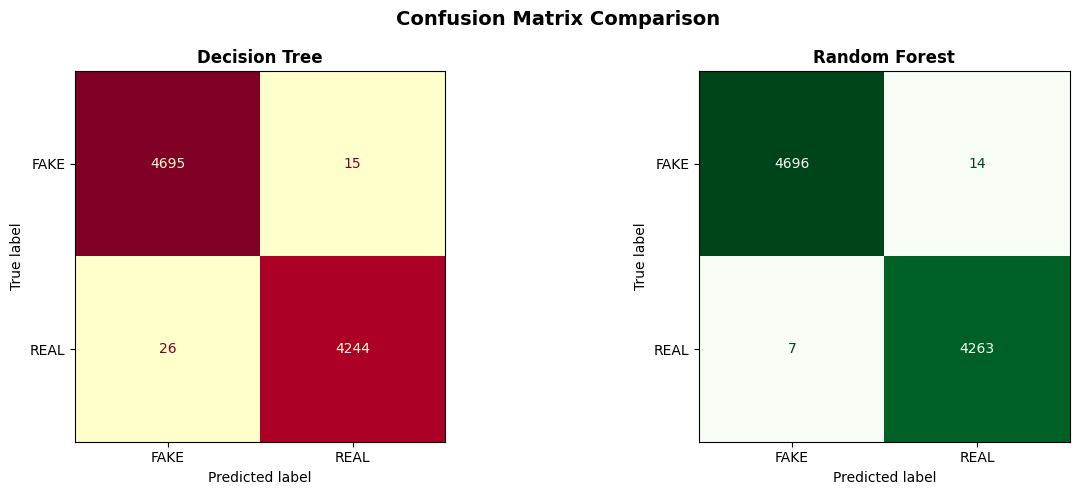


                            Decision Tree   Random Forest
 Correctly predicted FAKE:               4695            4696
 Correctly predicted real:               4244            4263
 Fake predicted as Real:               15              14
 Real predicted as Fake:               26               7
 Total FAKE:                     41              21


In [11]:
# Random Forest  Confusion Matrix
rf_preds = ml_results['Random Forest']['model'].predict(X_test_vec)

cm_rf = confusion_matrix(y_test, rf_preds, labels=['FAKE', 'REAL'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Decision Tree
cm_dt = confusion_matrix(y_test, 
        ml_results['Decision Tree']['model'].predict(X_test_vec), 
        labels=['FAKE', 'REAL'])
ConfusionMatrixDisplay(cm_dt, 
    display_labels=['FAKE','REAL']).plot(ax=axes[0], 
    cmap='YlOrRd', colorbar=False)
axes[0].set_title('Decision Tree', fontweight='bold')

# Random Forest
ConfusionMatrixDisplay(cm_rf, 
    display_labels=['FAKE','REAL']).plot(ax=axes[1], 
    cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest', fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Numbers compare 
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print(f"\n{'':25} {'Decision Tree':>15} {'Random Forest':>15}")
print("=" * 55)
print(f" Correctly predicted FAKE:    {tn_dt:>15} {tn_rf:>15}")
print(f" Correctly predicted real:    {tp_dt:>15} {tp_rf:>15}")
print(f" Fake predicted as Real:  {fp_dt:>15} {fp_rf:>15}")
print(f" Real predicted as Fake:  {fn_dt:>15} {fn_rf:>15}")
print("=" * 55)
print(f" Total FAKE:        {fp_dt+fn_dt:>15} {fp_rf+fn_rf:>15}")

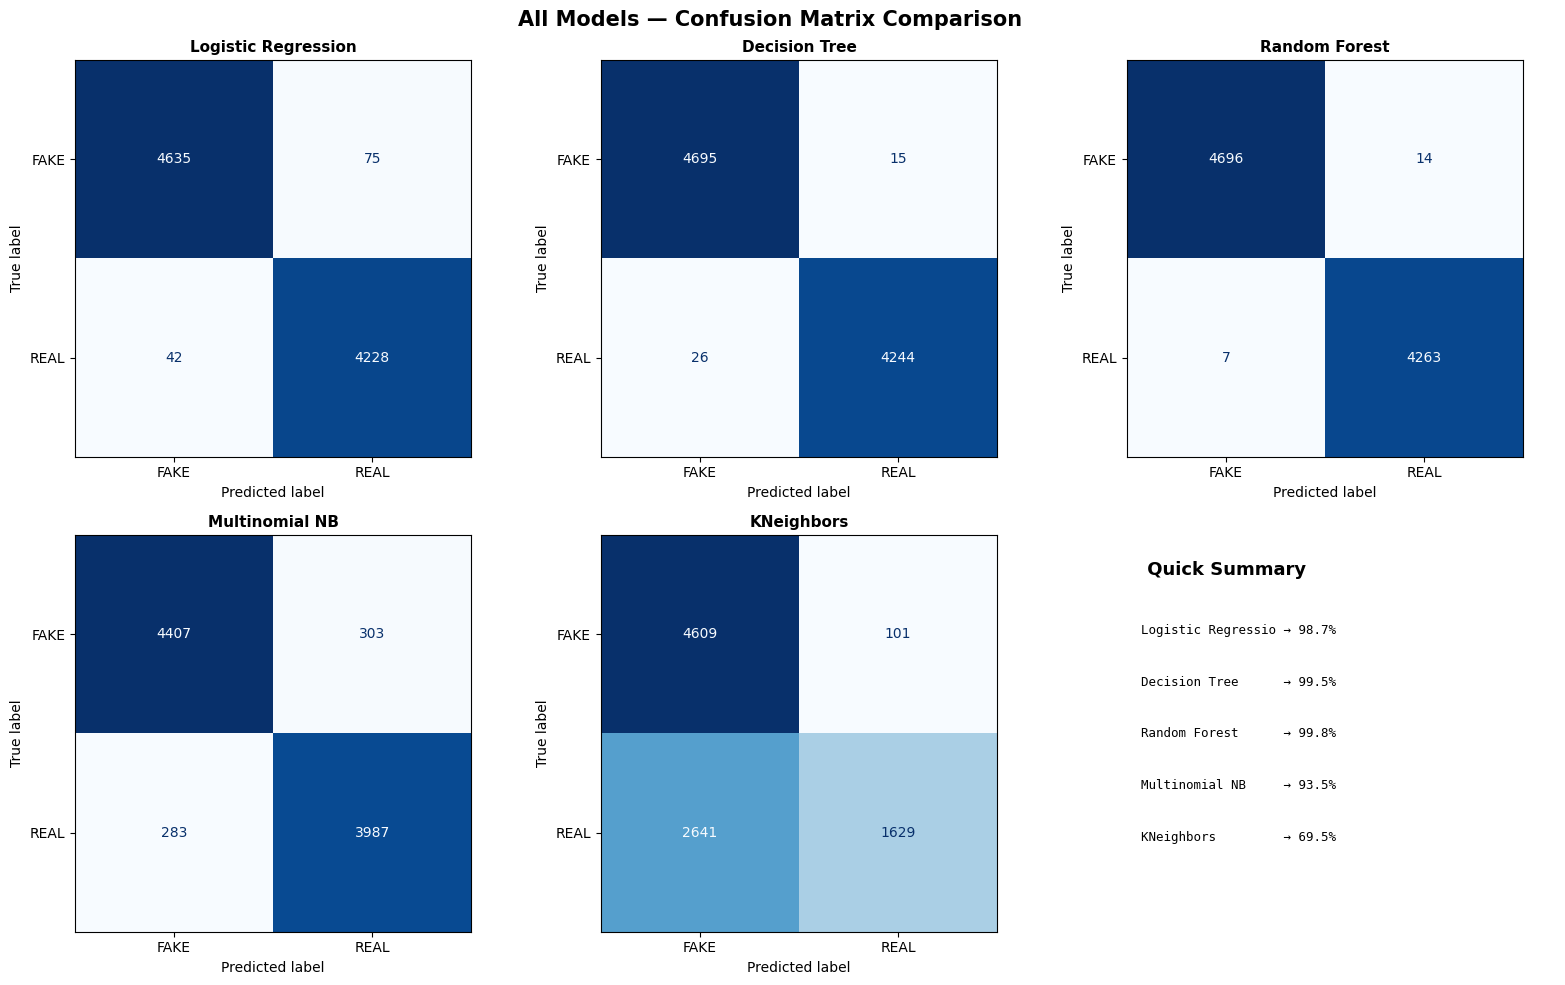


 Complete Model Comparison — Precision, Recall, F1 Score
              Model Accuracy Precision Recall F1 Score  Correct  Wrong
      Random Forest   99.77%    99.67% 99.84%   99.75%     8959     21
      Decision Tree   99.54%    99.65% 99.39%   99.52%     8939     41
Logistic Regression    98.7%    98.26% 99.02%   98.64%     8863    117
     Multinomial NB   93.47%    92.94% 93.37%   93.15%     8394    586
         KNeighbors   69.47%    94.16% 38.15%    54.3%     6238   2742


In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

all_results = []

models_list = list(ml_results.keys())

for i, name in enumerate(models_list):
    preds = ml_results[name]['model'].predict(X_test_vec)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds, labels=['FAKE', 'REAL'])
    ConfusionMatrixDisplay(cm, display_labels=['FAKE','REAL']).plot(
        ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}', fontweight='bold', fontsize=11)
    
    # Metrics calculate 
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, pos_label='REAL')
    rec  = recall_score(y_test, preds, pos_label='REAL')
    f1   = f1_score(y_test, preds, pos_label='REAL')
    
    tn, fp, fn, tp = cm.ravel()
    
    all_results.append({
        'Model':      name,
        'Accuracy':   acc,
        'Precision':  prec,
        'Recall':     rec,
        'F1 Score':   f1,
        'Correct':    tn + tp,
        'Wrong':      fp + fn,
    })

# 6th plot empty — summary table 
axes[5].axis('off')
axes[5].text(0.1, 0.9, ' Quick Summary', 
             fontsize=13, fontweight='bold',
             transform=axes[5].transAxes)

for j, r in enumerate(all_results):
    axes[5].text(0.1, 0.75 - j*0.13,
                 f"{r['Model'][:18]:<18} → {r['Accuracy']*100:.1f}%",
                 fontsize=9, transform=axes[5].transAxes,
                 fontfamily='monospace')

plt.suptitle('All Models — Confusion Matrix Comparison', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Complete Metrics Table ───
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

#convert into precentage 
for col in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    results_df[col] = (results_df[col] * 100).round(2).astype(str) + '%'

print("\n Complete Model Comparison — Precision, Recall, F1 Score")
print("=" * 75)
print(results_df.to_string(index=False))
print("=" * 75)


LSTM



In [13]:
# LSTM 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
MAX_WORDS = 10000   # Vocabulary size
MAX_LEN   = 300     #  max length (words)

# Tokenizer 
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# text convert into numbers 
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Sab sequences 
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# Label encode  (FAKE=0, REAL=1)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f" Vocabulary size:     {len(tokenizer.word_index)}")
print(f" X_train shape:       {X_train_pad.shape}")
print(f" X_test shape:        {X_test_pad.shape}")
print(f" Labels: {le.classes_}  →  {list(range(len(le.classes_)))}")


 Vocabulary size:     189657
 X_train shape:       (35918, 300)
 X_test shape:        (8980, 300)
 Labels: ['FAKE' 'REAL']  →  [0, 1]


LSTM: Model Architecture

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Model 
model = Sequential([
    # Step 1: words convert into dense 
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    
    # Step 2: Bidirectional LSTM — read both sides
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    
    # Step 3:  LSTM layer
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    
    # Step 4: Dense layers — understanding pattern
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    # Step 5: Final output — FAKE or REAL
    Dense(1, activation='sigmoid')
])

# Model compile 
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



In [15]:
# Early Stopping 
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,              # 2 epochs 
    restore_best_weights=True
)

# Model train 
print(" Training.....")
print(" Patience  \n")

history = model.fit(
    X_train_pad, y_train_enc,
    epochs=10,
    batch_size=64,
    validation_split=0.1,     # 10% validation 
    callbacks=[early_stop],
    verbose=1
)

print("\n Training complete!")  

 Training.....
 Patience  

Epoch 1/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 357s 692ms/step - accuracy: 0.9830 - loss: 0.0415 - val_accuracy: 0.9981 - val_loss: 0.0080
Epoch 2/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 315s 623ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9983 - val_loss: 0.0068
Epoch 3/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 243s 479ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accuracy: 0.9986 - val_loss: 0.0051
Epoch 4/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 254s 501ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9975 - val_loss: 0.0151
Epoch 5/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 247s 488ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9981 - val_loss: 0.0084

 Training complete!


In [16]:
# LSTM Evaluate 
print(" LSTM Final Evaluation on Test Set:")
print("=" * 40)

loss, acc = model.evaluate(X_test_pad, y_test_enc, verbose=0)
print(f" Test Accuracy: {acc*100:.2f}%")
print(f" Test Loss:     {loss:.4f}")

# Detailed report
y_pred = (model.predict(X_test_pad, verbose=0) > 0.5).astype(int).flatten()

print("\n Classification Report:")
print(classification_report(y_test_enc, y_pred, 
      target_names=['FAKE', 'REAL']))


 LSTM Final Evaluation on Test Set:
 Test Accuracy: 99.84%
 Test Loss:     0.0079

 Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      4710
        REAL       1.00      1.00      1.00      4270

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



 LSTM Overfitting Check
Train Accuracy: 99.96%
Val Accuracy:   99.81%
Gap:            0.16%
 Normal — No Overfitting!


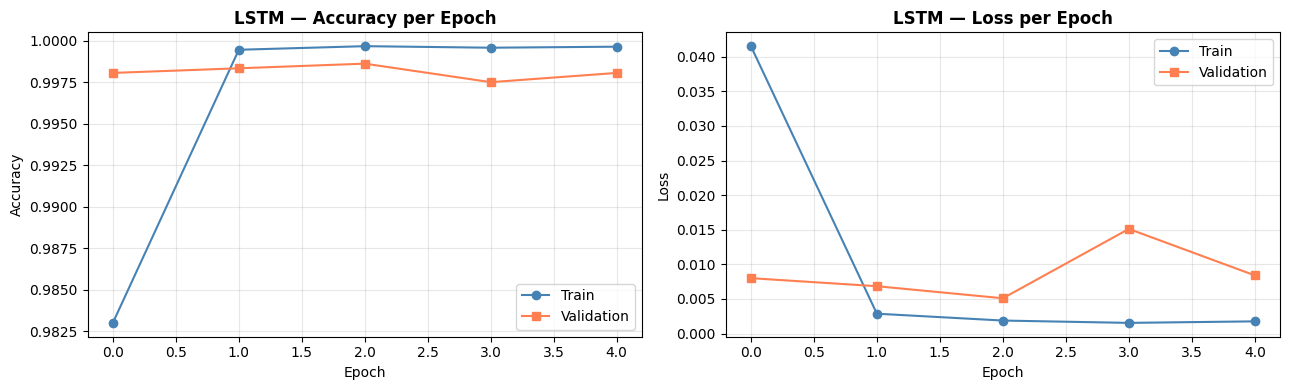

In [20]:
# Training history check
train_acc_final = history.history['accuracy'][-1]
val_acc_final   = history.history['val_accuracy'][-1]
gap             = train_acc_final - val_acc_final

print(" LSTM Overfitting Check")
print("=" * 40)
print(f"Train Accuracy: {train_acc_final*100:.2f}%")
print(f"Val Accuracy:   {val_acc_final*100:.2f}%")
print(f"Gap:            {gap*100:.2f}%")
print("=" * 40)

if gap < 0.02:
    print(" Normal — No Overfitting!")
elif gap < 0.05:
    print(" Slight Overfitting")
else:
    print(" Overfitting Detected!")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'],
         'o-', color='steelblue', label='Train')
ax1.plot(history.history['val_accuracy'],
         's-', color='coral', label='Validation')
ax1.set_title('LSTM — Accuracy per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'],
         'o-', color='steelblue', label='Train')
ax2.plot(history.history['val_loss'],
         's-', color='coral', label='Validation')
ax2.set_title('LSTM — Loss per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
import pickle
import os

# Models folder create
os.makedirs('models', exist_ok=True)

# LSTM model save 
model.save('models/lstm_model.h5')

# Tokenizer save 
with open('models/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Best ML model save (Random Forest)
with open('models/rf_model.pkl', 'wb') as f:
    pickle.dump(ml_results['Random Forest']['model'], f)

# TF-IDF Vectorizer save karo
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print(" All models saved!")
print("\nSaved files:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / (1024*1024)
    print(f"   {f} — {size:.1f} MB")


 All models saved!

Saved files:
   lstm_model.h5 — 16.4 MB
   lstm_tokenizer.pkl — 8.5 MB
   rf_model.pkl — 28.5 MB
   tfidf_vectorizer.pkl — 0.2 MB


In [22]:
# Test karo notebook mein same text se
test_text = """President Obama signed the healthcare reform bill into law on Tuesday, 
marking a significant victory for his administration. The legislation 
aims to provide affordable health insurance to millions of uninsured 
Americans. Congressional leaders from both parties attended the 
signing ceremony at the White House."""

clean = preprocess_text(test_text)
seq   = tokenizer.texts_to_sequences([clean])
pad   = pad_sequences(seq, maxlen=300, padding='post', truncating='post')
prob  = model.predict(pad, verbose=0)[0][0]

print(f"Probability: {prob:.4f}")
print(f"Result: {'REAL' if prob > 0.5 else 'FAKE'}")

Probability: 0.0001
Result: FAKE


In [ ]:
# label_enc column 
df['label_enc'] = df['label'].map({'REAL': 1, 'FAKE': 0})

print(df.columns.tolist())
print(df['label_enc'].value_counts())


['text', 'label', 'clean_text', 'label_enc']
label_enc
0    23481
1    21417
Name: count, dtype: int64


In [25]:
print(df.columns.tolist())
print(df['label_enc'].value_counts())

['text', 'label', 'clean_text', 'label_enc']
label_enc
0    23481
1    21417
Name: count, dtype: int64


In [32]:
import numpy as np

# Sirf 10000 rows 
df_small = df.sample(n=10000, random_state=42).reset_index(drop=True)

# List  convert 
X_lstm_raw = df_small['text'].fillna('').tolist()
y_lstm_raw = df_small['label_enc'].tolist()

# Split
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_lstm_raw, y_lstm_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_lstm_raw
)

# Tokenize
MAX_WORDS2 = 20000
MAX_LEN2   = 300

tokenizer2 = Tokenizer(num_words=MAX_WORDS2, oov_token='<OOV>')
tokenizer2.fit_on_texts(X_tr2)

X_tr2_seq = tokenizer2.texts_to_sequences(X_tr2)
X_te2_seq = tokenizer2.texts_to_sequences(X_te2)

X_tr2_pad = pad_sequences(X_tr2_seq, maxlen=MAX_LEN2,
                           padding='post', truncating='post')
X_te2_pad = pad_sequences(X_te2_seq, maxlen=MAX_LEN2,
                           padding='post', truncating='post')

y_tr2 = np.array(y_tr2)
y_te2 = np.array(y_te2)

print(f" Train shape: {X_tr2_pad.shape}")
print(f" Test shape:  {X_te2_pad.shape}")
print(f" RAM issue fix !")

 Train shape: (8000, 300)
 Test shape:  (2000, 300)
 RAM issue fix !


In [33]:
# New model
vocab_size2 = min(MAX_WORDS2, len(tokenizer2.word_index) + 1)

model2 = Sequential([
    Embedding(input_dim=vocab_size2, output_dim=128,
              input_length=MAX_LEN2),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

print(" Training start...")
history2 = model2.fit(
    X_tr2_pad, y_tr2,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop2],
    verbose=1
)

print("\n Training complete!")

 Training start...
Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 70s 527ms/step - accuracy: 0.9392 - loss: 0.1609 - val_accuracy: 0.9987 - val_loss: 0.0048
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 64s 562ms/step - accuracy: 0.9990 - loss: 0.0042 - val_accuracy: 0.9950 - val_loss: 0.0174
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 64s 564ms/step - accuracy: 1.0000 - loss: 4.4323e-04 - val_accuracy: 0.9975 - val_loss: 0.0069

 Training complete!


In [34]:
import json

# New model save 
model2.save('models/lstm_model.h5')

with open('models/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer2, f)

with open('models/config.json', 'w') as f:
    json.dump({'MAX_LEN': MAX_LEN2}, f)

print(" New model saved!")
print(" Tokenizer saved!")
print(" Config saved!")

 New model saved!
 Tokenizer saved!
 Config saved!


In [ ]:
# Dataset  REAL news 
real_samples = df[df['label'] == 'REAL']['text'].head(3).values
fake_samples = df[df['label'] == 'FAKE']['text'].head(3).values

print("=== REAL NEWS SAMPLES ===")
for i, text in enumerate(real_samples):
    print(f"\nSample {i+1}:")
    print(text[:200])
    print("---")

print("\n=== FAKE NEWS SAMPLES ===")
for i, text in enumerate(fake_samples):
    print(f"\nSample {i+1}:")
    print(text[:200])
    print("---")

=== REAL NEWS SAMPLES ===

Sample 1:
WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to gi
---

Sample 2:
(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the Jones Act, which would lift restrictions on ships that can provide aid to the island
---

Sample 3:
GLASGOW, Scotland (Reuters) - Most U.S. presidential candidates go abroad to sharpen their foreign policy credentials. Donald Trump arrives in Scotland on Friday to reopen a golf resort. The presumpti
---

=== FAKE NEWS SAMPLES ===

Sample 1:
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative s
---

Sample 2:
On Monday, Donald Trump once again embarrassed himself and his country b

In [36]:
# Dataset ka actual REAL article test karo
test_real = """WASHINGTON (Reuters) - U.S. President Donald Trump removed 
his chief strategist Steve Bannon from the National Security Council 
on Wednesday, reversing his controversial decision early this year."""

from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle, json, tensorflow as tf

# Load fresh
m2 = tf.keras.models.load_model('models/lstm_model.h5')
with open('models/lstm_tokenizer.pkl', 'rb') as f:
    tok2 = pickle.load(f)
with open('models/config.json', 'r') as f:
    cfg2 = json.load(f)

print(f"MAX_LEN: {cfg2['MAX_LEN']}")

seq  = tok2.texts_to_sequences([test_real])
pad  = pad_sequences(seq, maxlen=cfg2['MAX_LEN'],
                     padding='post', truncating='post')
prob = m2.predict(pad, verbose=0)[0][0]

print(f"Probability: {prob:.4f}")
print(f"Result: {'REAL' if prob > 0.5 else 'FAKE'}")

MAX_LEN: 300
Probability: 0.9992
Result: REAL
